In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv("D:/St Anns/AI/Supply Chain/Data/enhanced/walmart_final_with_trends.csv")
data.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,GoogleTrends_furniture_lag4,GoogleTrends_sports equipment_lag1,GoogleTrends_sports equipment_lag2,GoogleTrends_sports equipment_lag4,GoogleTrends_beauty products_lag1,GoogleTrends_beauty products_lag2,GoogleTrends_beauty products_lag4,GoogleTrends_home decor_lag1,GoogleTrends_home decor_lag2,GoogleTrends_home decor_lag4
0,1,1,2010-02-05,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,38.51,2.548,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,2010-02-19,41595.55,39.93,2.514,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1,2010-02-26,19403.54,46.63,2.561,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1,2010-03-05,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,...,96.0,92.0,100.0,85.0,100.0,89.0,100.0,92.0,96.0,100.0


In [3]:
data["Date"] = pd.to_datetime(data["Date"])
data['IsHoliday']

0         False
1          True
2         False
3         False
4         False
          ...  
420280    False
420281    False
420282    False
420283    False
420284    False
Name: IsHoliday, Length: 420285, dtype: bool

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [5]:
label_encoder_hol = LabelEncoder()
data['IsHoliday'] = label_encoder_hol.fit_transform(data['IsHoliday'])
data['IsHoliday']

0         0
1         1
2         0
3         0
4         0
         ..
420280    0
420281    0
420282    0
420283    0
420284    0
Name: IsHoliday, Length: 420285, dtype: int64

In [6]:
data.dtypes

Store                                          int64
Dept                                           int64
Date                                  datetime64[ns]
Weekly_Sales                                 float64
Temperature                                  float64
Fuel_Price                                   float64
MarkDown1                                    float64
MarkDown2                                    float64
MarkDown3                                    float64
MarkDown4                                    float64
MarkDown5                                    float64
CPI                                          float64
Unemployment                                 float64
Type                                          object
Size                                           int64
IsHoliday                                      int64
YearWeek                                      object
GoogleTrends_electronics                     float64
GoogleTrends_groceries                       f

In [7]:
from sklearn.preprocessing import OneHotEncoder

In [8]:
onehot_encoder_type = OneHotEncoder()
type_encoder = onehot_encoder_type.fit_transform(data[['Type']]).toarray()
type_encoder

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], shape=(420285, 3))

In [9]:
data.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Type', 'Size', 'IsHoliday', 'YearWeek',
       'GoogleTrends_electronics', 'GoogleTrends_groceries',
       'GoogleTrends_clothing', 'GoogleTrends_toys', 'GoogleTrends_furniture',
       'GoogleTrends_sports equipment', 'GoogleTrends_beauty products',
       'GoogleTrends_home decor', 'GoogleTrends_electronics_lag1',
       'GoogleTrends_electronics_lag2', 'GoogleTrends_electronics_lag4',
       'GoogleTrends_groceries_lag1', 'GoogleTrends_groceries_lag2',
       'GoogleTrends_groceries_lag4', 'GoogleTrends_clothing_lag1',
       'GoogleTrends_clothing_lag2', 'GoogleTrends_clothing_lag4',
       'GoogleTrends_toys_lag1', 'GoogleTrends_toys_lag2',
       'GoogleTrends_toys_lag4', 'GoogleTrends_furniture_lag1',
       'GoogleTrends_furniture_lag2', 'GoogleTrends_furniture_lag4',
       'GoogleTrends_sports equi

In [10]:
type_df = pd.DataFrame(type_encoder, columns = onehot_encoder_type.get_feature_names_out(['Type']))
type_df

,Type_A,Type_B,Type_C
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
420280,0.0,1.0,0.0
420281,0.0,1.0,0.0
420282,0.0,1.0,0.0
420283,0.0,1.0,0.0


In [11]:
data = pd.concat([data.drop('Type', axis = 1), type_df], axis = 1)
data.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,GoogleTrends_sports equipment_lag4,GoogleTrends_beauty products_lag1,GoogleTrends_beauty products_lag2,GoogleTrends_beauty products_lag4,GoogleTrends_home decor_lag1,GoogleTrends_home decor_lag2,GoogleTrends_home decor_lag4,Type_A,Type_B,Type_C
0,1,1,2010-02-05,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
1,1,1,2010-02-12,46039.49,38.51,2.548,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
2,1,1,2010-02-19,41595.55,39.93,2.514,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
3,1,1,2010-02-26,19403.54,46.63,2.561,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
4,1,1,2010-03-05,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,...,85.0,100.0,89.0,100.0,92.0,96.0,100.0,1.0,0.0,0.0


In [12]:
import pickle

In [13]:
with open('label_encoder_hol.pkl', 'wb') as file:
    pickle.dump(label_encoder_hol, file)
with open('onehot_encoder_type.pkl', 'wb') as file:
    pickle.dump(onehot_encoder_type, file)

In [14]:
data.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Size', 'IsHoliday', 'YearWeek',
       'GoogleTrends_electronics', 'GoogleTrends_groceries',
       'GoogleTrends_clothing', 'GoogleTrends_toys', 'GoogleTrends_furniture',
       'GoogleTrends_sports equipment', 'GoogleTrends_beauty products',
       'GoogleTrends_home decor', 'GoogleTrends_electronics_lag1',
       'GoogleTrends_electronics_lag2', 'GoogleTrends_electronics_lag4',
       'GoogleTrends_groceries_lag1', 'GoogleTrends_groceries_lag2',
       'GoogleTrends_groceries_lag4', 'GoogleTrends_clothing_lag1',
       'GoogleTrends_clothing_lag2', 'GoogleTrends_clothing_lag4',
       'GoogleTrends_toys_lag1', 'GoogleTrends_toys_lag2',
       'GoogleTrends_toys_lag4', 'GoogleTrends_furniture_lag1',
       'GoogleTrends_furniture_lag2', 'GoogleTrends_furniture_lag4',
       'GoogleTrends_sports equipment_la

In [15]:
data.dtypes

Store                                          int64
Dept                                           int64
Date                                  datetime64[ns]
Weekly_Sales                                 float64
Temperature                                  float64
Fuel_Price                                   float64
MarkDown1                                    float64
MarkDown2                                    float64
MarkDown3                                    float64
MarkDown4                                    float64
MarkDown5                                    float64
CPI                                          float64
Unemployment                                 float64
Size                                           int64
IsHoliday                                      int64
YearWeek                                      object
GoogleTrends_electronics                     float64
GoogleTrends_groceries                       float64
GoogleTrends_clothing                        f

In [16]:
from sklearn.model_selection import train_test_split

In [50]:
x = data[['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'IsHoliday', 'Type_A', 'Type_B', 'Type_C']]
y = data['Weekly_Sales']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train

array([[-0.87525698, -0.27152668,  1.24374974, ...,  0.97684346,
        -0.79489489, -0.33534114],
       [ 1.70470671, -0.40262533, -1.4603797 , ..., -1.02370548,
        -0.79489489,  2.98203795],
       [ 0.68835738, -1.02534393,  0.30676645, ...,  0.97684346,
        -0.79489489, -0.33534114],
       ...,
       [-0.64071483, -0.4354    ,  0.96178718, ...,  0.97684346,
        -0.79489489, -0.33534114],
       [-0.56253411,  1.56385446, -0.02887745, ..., -1.02370548,
         1.25802796, -0.33534114],
       [-0.71889554, -0.33707601,  0.54697687, ...,  0.97684346,
        -0.79489489, -0.33534114]], shape=(336228, 11))

In [51]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime

In [53]:
model = Sequential([
    Dense(64, activation = 'relu', input_shape = (x_train.shape[1],)), ## HL1
    Dense(32, activation = 'relu'), ## HL2
    Dense(1, activation = 'sigmoid') ## Output layer
]
)

In [54]:
## Backward propagation

import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate = 0.01)
loss = tensorflow.keras.losses.BinaryCrossentropy()
loss

<LossFunctionWrapper(<function binary_crossentropy at 0x0000019474E26840>, kwargs={'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>

In [55]:
## Compile the model

model.compile(optimizer = opt, loss = "binary_crossentropy", metrics = ['accuracy'])

In [56]:
## Set up the tensorboard

from tensorflow.keras.callbacks import EarlyStopping

In [57]:
## Set up Early Stopping

early_stopping_callbacks = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

In [58]:
## Train the model
history = model.fit(
    x_train, y_train, validation_data = (x_test, y_test), epochs = 10,
    callbacks = [early_stopping_callbacks]
)

Epoch 1/10
10508/10508 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 3.9259e-04 - loss: -27880295759872.0000 - val_accuracy: 4.4018e-04 - val_loss: -97248553730048.0000
Epoch 2/10
10508/10508 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 3.9259e-04 - loss: -285962848436224.0000 - val_accuracy: 4.4018e-04 - val_loss: -557885046128640.0000
Epoch 3/10
10508/10508 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 3.9259e-04 - loss: -1021321546825728.0000 - val_accuracy: 4.4018e-04 - val_loss: -1611675069317120.0000
Epoch 4/10
10508/10508 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 3.9259e-04 - loss: -2454487641882624.0000 - val_accuracy: 4.4018e-04 - val_loss: -3477602270445568.0000
Epoch 5/10
10508/10508 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 3.9259e-04 - loss: -4819118125481984.0000 - val_accuracy: 4.4018e-04 - val_loss: -6383435408998400.0000
Epoch 6/10
10508/10508 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 3.9259e-04 - loss: -8320253058613248.0000 - val_accuracy: 4.4018e-04 - v

In [59]:
model.save('model.keras')

In [1]:
test_cases = [(1,1),(1,2),(1,3),(1,4),(1,5),(1,6),(1,7),(1,8),(1,9),(1,10),(1,11),(1,12),(1,13),(1,14),(1,16),(1,17),(1,18),(1,19),(1,20),(1,21),(1,22),(1,23),(1,24),(1,25),(1,26),(1,27),(1,28),(1,29),(1,30),(1,31),(1,32),(1,33),(1,34),(1,35),(1,36),(1,37),(1,38),(1,40),(1,41),(1,42),(1,44),(1,45),(1,46),(1,47),(1,48),(1,49),(1,51),(1,52),(1,54),(1,55),(1,56),(1,58),(1,59),(1,60),(1,67),(1,71),(1,72),(1,74),(1,77),(1,78),(1,79),(1,80),(1,81),(1,82),(1,83),(1,85),(1,87),(1,90),(1,91),(1,92),(1,93),(1,94),(1,95),(1,96),(1,97),(1,98),(1,99),(2,1),(2,2),(2,3),(2,4),(2,5),(2,6),(2,7),(2,8),(2,9),(2,10),(2,11),(2,12),(2,13),(2,14),(2,16),(2,17),(2,18),(2,19),(2,20),(2,21),(2,22),(2,23),(2,24),(2,25),(2,26),(2,27),(2,28),(2,29),(2,30),(2,31),(2,32),(2,33),(2,34),(2,35),(2,36),(2,37),(2,38),(2,39),(2,40),(2,41),(2,42),(2,44),(2,45),(2,46),(2,47),(2,48),(2,49),(2,51),(2,52),(2,54),(2,55),(2,56),(2,58),(2,59),(2,60),(2,67),(2,71),(2,72),(2,74),(2,77),(2,78),(2,79),(2,80),(2,81),(2,82),(2,83),(2,85),(2,87),(2,90),(2,91),(2,92),(2,93),(2,94),(2,95),(2,96),(2,97),(2,98),(2,99),(3,1),(3,2),(3,3),(3,4),(3,5),(3,6),(3,7),(3,8),(3,9),(3,10),(3,11),(3,12),(3,13),(3,14),(3,16),(3,17),(3,18),(3,19),(3,20),(3,21),(3,22),(3,23),(3,24),(3,25),(3,26),(3,27),(3,28),(3,29),(3,30),(3,31),(3,32),(3,33),(3,34),(3,35),(3,36),(3,38),(3,40),(3,41),(3,42),(3,44),(3,45),(3,46),(3,47),(3,49),(3,51),(3,52),(3,54),(3,55),(3,56),(3,59),(3,60),(3,67),(3,71),(3,72),(3,74),(3,77),(3,78),(3,79),(3,80),(3,81),(3,82),(3,83),(3,85),(3,87),(3,90),(3,91),(3,92),(3,94),(3,95),(3,96),(3,97),(3,98),(4,1),(4,2),(4,3),(4,4),(4,5),(4,6),(4,7),(4,8),(4,9),(4,10),(4,11),(4,12),(4,13),(4,14),(4,16),(4,17),(4,18),(4,19),(4,20),(4,21),(4,22),(4,23),(4,24),(4,25),(4,26),(4,27),(4,28),(4,29),(4,30),(4,31),(4,32),(4,33),(4,34),(4,35),(4,36),(4,37),(4,38),(4,39),(4,40),(4,41),(4,42),(4,44),(4,45),(4,46),(4,47),(4,48),(4,49),(4,51),(4,52),(4,54),(4,55),(4,56),(4,58),(4,59),(4,60),(4,67),(4,71),(4,72),(4,74),(4,77),(4,78),(4,79),(4,80),(4,81),(4,82),(4,83),(4,85),(4,87),(4,90),(4,91),(4,92),(4,93),(4,94),(4,95),(4,96),(4,97),(4,98),(4,99),(5,1),(5,2),(5,3),(5,4),(5,5),(5,6),(5,7),(5,8),(5,9),(5,10),(5,11),(5,12),(5,13),(5,14),(5,16),(5,17),(5,18),(5,19),(5,20),(5,21),(5,22),(5,23),(5,24),(5,25),(5,26),(5,27),(5,28),(5,29),(5,30),(5,31),(5,32),(5,33),(5,34),(5,35),(5,36),(5,38),(5,40),(5,41),(5,42),(5,44),(5,45),(5,46),(5,47),(5,49),(5,51),(5,52),(5,54),(5,55),(5,56),(5,58),(5,59),(5,60),(5,67),(5,71),(5,72),(5,74),(5,77),(5,78),(5,79),(5,80),(5,81),(5,82),(5,85),(5,87),(5,90),(5,91),(5,92),(5,94),(5,95),(5,96),(5,97),(5,98),(6,1),(6,2),(6,3),(6,4),(6,5),(6,6),(6,7),(6,8),(6,9),(6,10),(6,11),(6,12),(6,13),(6,14),(6,16),(6,17),(6,18),(6,19),(6,20),(6,21),(6,22),(6,23),(6,24),(6,25),(6,26),(6,27),(6,28),(6,29),(6,30),(6,31),(6,32),(6,33),(6,34),(6,35),(6,36),(6,37),(6,38),(6,40),(6,41),(6,42),(6,44),(6,45),(6,46),(6,47),(6,48),(6,49),(6,51),(6,52),(6,54),(6,55),(6,56),(6,58),(6,59),(6,60),(6,67),(6,71),(6,72),(6,74),(6,77),(6,78),(6,79),(6,80),(6,81),(6,82),(6,83),(6,85),(6,87),(6,90),(6,91),(6,92),(6,93),(6,94),(6,95),(6,96),(6,97),(6,98),(6,99),(7,1),(7,2),(7,3),(7,4),(7,5),(7,6),(7,7),(7,8),(7,9),(7,10),(7,11),(7,12),(7,13),(7,14),(7,16),(7,17),(7,18),(7,19),(7,20),(7,21),(7,22),(7,23),(7,24),(7,25),(7,26),(7,27),(7,28),(7,29),(7,30),(7,31),(7,32),(7,33),(7,34),(7,35),(7,36),(7,38),(7,40),(7,41),(7,42),(7,44),(7,45),(7,46),(7,47),(7,48),(7,49),(7,51),(7,52),(7,54),(7,55),(7,56),(7,58),(7,59),(7,60),(7,67),(7,71),(7,72),(7,74),(7,77),(7,78),(7,79),(7,80),(7,81),(7,82),(7,83),(7,85),(7,87),(7,90),(7,91),(7,92),(7,93),(7,94),(7,95),(7,96),(7,97),(7,98),(7,99),(8,1),(8,2),(8,3),(8,4),(8,5),(8,6),(8,7),(8,8),(8,9),(8,10),(8,11),(8,12),(8,13),(8,14),(8,16),(8,17),(8,18),(8,19),(8,20),(8,21),(8,22),(8,23),(8,24),(8,25),(8,26),(8,27),(8,28),(8,29),(8,30),(8,31),(8,32),(8,33),(8,34),(8,35),(8,36),(8,37),(8,38),(8,40),(8,41),(8,42),(8,44),(8,45),(8,46),(8,47),(8,49),(8,51),(8,52),(8,54),(8,55),(8,56),(8,58),(8,59),(8,60),(8,67),(8,71),(8,72),(8,74),(8,77),(8,78),(8,79),(8,80),(8,81),(8,82),(8,83),(8,85),(8,87),(8,90),(8,91),(8,92),(8,93),(8,94),(8,95),(8,96),(8,97),(8,98),(8,99),(9,1),(9,2),(9,3),(9,4),(9,5),(9,6),(9,7),(9,8),(9,9),(9,10),(9,11),(9,12),(9,13),(9,14),(9,16),(9,17),(9,18),(9,19),(9,20),(9,21),(9,22),(9,23),(9,24),(9,25),(9,26),(9,27),(9,28),(9,29),(9,30),(9,31),(9,32),(9,33),(9,34),(9,35),(9,36),(9,38),(9,40),(9,41),(9,42),(9,44),(9,45),(9,46),(9,47),(9,48),(9,49),(9,51),(9,52),(9,54),(9,55),(9,56),(9,59),(9,60),(9,67),(9,71),(9,72),(9,74),(9,77),(9,78),(9,79),(9,80),(9,81),(9,82),(9,85),(9,87),(9,90),(9,91),(9,92),(9,93),(9,94),(9,95),(9,96),(9,97),(9,98),(10,1),(10,2),(10,3),(10,4),(10,5),(10,6),(10,7),(10,8),(10,9),(10,10),(10,11),(10,12),(10,13),(10,14),(10,16),(10,17),(10,18),(10,19),(10,20),(10,21),(10,22),(10,23),(10,24),(10,25),(10,26),(10,27),(10,28),(10,29),(10,30),(10,31),(10,32),(10,33),(10,34),(10,35),(10,36),(10,37),(10,38),(10,40),(10,41),(10,42),(10,44),(10,45),(10,46),(10,47),(10,48),(10,49),(10,50),(10,51),(10,52),(10,54),(10,55),(10,56),(10,58),(10,59),(10,60),(10,67),(10,71),(10,72),(10,74),(10,77),(10,78),(10,79),(10,80),(10,81),(10,82),(10,83),(10,85),(10,87),(10,90),(10,91),(10,92),(10,93),(10,94),(10,95),(10,96),(10,97),(10,98),(11,1),(11,2),(11,3),(11,4),(11,5),(11,6),(11,7),(11,8),(11,9),(11,10),(11,11),(11,12),(11,13),(11,14),(11,16),(11,17),(11,18),(11,19),(11,20),(11,21),(11,22),(11,23),(11,24),(11,25),(11,26),(11,27),(11,28),(11,29),(11,30),(11,31),(11,32),(11,33),(11,34),(11,35),(11,36),(11,37),(11,38),(11,40),(11,41),(11,42),(11,44),(11,45),(11,46),(11,47),(11,48),(11,49),(11,50),(11,51),(11,52),(11,54),(11,55),(11,56),(11,58),(11,59),(11,60),(11,67),(11,71),(11,72),(11,74),(11,77),(11,78),(11,79),(11,80),(11,81),(11,82),(11,83),(11,85),(11,87),(11,90),(11,91),(11,92),(11,93),(11,94),(11,95),(11,96),(11,97),(11,98),(11,99),(12,1),(12,2),(12,3),(12,4),(12,5),(12,6),(12,7),(12,8),(12,9),(12,10),(12,11),(12,12),(12,13),(12,14),(12,16),(12,17),(12,18),(12,19),(12,20),(12,21),(12,22),(12,23),(12,24),(12,25),(12,26),(12,27),(12,28),(12,29),(12,30),(12,31),(12,32),(12,33),(12,34),(12,35),(12,36),(12,38),(12,40),(12,41),(12,42),(12,44),(12,45),(12,46),(12,47),(12,49),(12,51),(12,52),(12,54),(12,55),(12,56),(12,58),(12,59),(12,60),(12,67),(12,71),(12,72),(12,74),(12,77),(12,78),(12,79),(12,80),(12,81),(12,82),(12,83),(12,85),(12,87),(12,90),(12,91),(12,92),(12,93),(12,94),(12,95),(12,96),(12,97),(12,98),(12,99),(13,1),(13,2),(13,3),(13,4),(13,5),(13,6),(13,7),(13,8),(13,9),(13,10),(13,11),(13,12),(13,13),(13,14),(13,16),(13,17),(13,18),(13,19),(13,20),(13,21),(13,22),(13,23),(13,24),(13,25),(13,26),(13,27),(13,28),(13,29),(13,30),(13,31),(13,32),(13,33),(13,34),(13,35),(13,36),(13,37),(13,38),(13,40),(13,41),(13,42),(13,43),(13,44),(13,45),(13,46),(13,47),(13,48),(13,49),(13,50),(13,51),(13,52),(13,54),(13,55),(13,56),(13,58),(13,59),(13,60),(13,67),(13,71),(13,72),(13,74),(13,77),(13,78),(13,79),(13,80),(13,81),(13,82),(13,83),(13,85),(13,87),(13,90),(13,91),(13,92),(13,93),(13,94),(13,95),(13,96),(13,97),(13,98),(13,99),(14,1),(14,2),(14,3),(14,4),(14,5),(14,6),(14,7),(14,8),(14,9),(14,10),(14,11),(14,12),(14,13),(14,14),(14,16),(14,17),(14,18),(14,19),(14,20),(14,21),(14,22),(14,23),(14,24),(14,25),(14,26),(14,27),(14,28),(14,29),(14,30),(14,31),(14,32),(14,33),(14,34),(14,35),(14,36),(14,38),(14,40),(14,41),(14,42),(14,43),(14,44),(14,45),(14,46),(14,47),(14,49),(14,50),(14,51),(14,52),(14,54),(14,55),(14,56),(14,58),(14,59),(14,60),(14,67),(14,71),(14,72),(14,74),(14,77),(14,78),(14,79),(14,80),(14,81),(14,82),(14,83),(14,85),(14,87),(14,90),(14,91),(14,92),(14,93),(14,94),(14,95),(14,96),(14,97),(14,98),(14,99),(15,1),(15,2),(15,3),(15,4),(15,5),(15,6),(15,7),(15,8),(15,9),(15,10),(15,11),(15,12),(15,13),(15,14),(15,16),(15,17),(15,18),(15,19),(15,20),(15,21),(15,22),(15,23),(15,24),(15,25),(15,26),(15,27),(15,28),(15,29),(15,30),(15,31),(15,32),(15,33),(15,34),(15,35),(15,36),(15,38),(15,40),(15,41),(15,42),(15,43),(15,44),(15,45),(15,46),(15,47),(15,48),(15,49),(15,50),(15,51),(15,52),(15,54),(15,55),(15,56),(15,58),(15,59),(15,60),(15,67),(15,71),(15,72),(15,74),(15,77),(15,78),(15,79),(15,80),(15,81),(15,82),(15,83),(15,85),(15,87),(15,90),(15,91),(15,92),(15,93),(15,94),(15,95),(15,96),(15,97),(15,98),(15,99),(16,1),(16,2),(16,3),(16,4),(16,5),(16,6),(16,7),(16,8),(16,9),(16,10),(16,11),(16,12),(16,13),(16,14),(16,16),(16,17),(16,18),(16,19),(16,20),(16,21),(16,22),(16,23),(16,24),(16,25),(16,26),(16,27),(16,28),(16,29),(16,30),(16,31),(16,32),(16,33),(16,34),(16,35),(16,36),(16,38),(16,40),(16,41),(16,42),(16,44),(16,45),(16,46),(16,47),(16,48),(16,49),(16,51),(16,52),(16,54),(16,55),(16,56),(16,58),(16,59),(16,60),(16,67),(16,71),(16,72),(16,74),(16,77),(16,78),(16,79),(16,80),(16,81),(16,82),(16,83),(16,85),(16,87),(16,90),(16,91),(16,92),(16,93),(16,94),(16,95),(16,96),(16,97),(16,98),(16,99),(17,1),(17,2),(17,3),(17,4),(17,5),(17,6),(17,7),(17,8),(17,9),(17,10),(17,11),(17,12),(17,13),(17,14),(17,16),(17,17),(17,18),(17,19),(17,20),(17,21),(17,22),(17,23),(17,24),(17,25),(17,26),(17,27),(17,28),(17,29),(17,30),(17,31),(17,32),(17,33),(17,34),(17,35),(17,36),(17,38),(17,40),(17,41),(17,42),(17,44),(17,45),(17,46),(17,47),(17,48),(17,49),(17,51),(17,52),(17,54),(17,55),(17,56),(17,58),(17,59),(17,60),(17,67),(17,71),(17,72),(17,74),(17,77),(17,78),(17,79),(17,80),(17,81),(17,82),(17,83),(17,85),(17,87),(17,90),(17,91),(17,92),(17,93),(17,94),(17,95),(17,96),(17,97),(17,98),(17,99),(18,1),(18,2),(18,3),(18,4),(18,5),(18,6),(18,7),(18,8),(18,9),(18,10),(18,11),(18,12),(18,13),(18,14),(18,16),(18,17),(18,18),(18,19),(18,20),(18,21),(18,22),(18,23),(18,24),(18,25),(18,26),(18,27),(18,28),(18,29),(18,30),(18,31),(18,32),(18,33),(18,34),(18,35),(18,36),(18,38),(18,39),(18,40),(18,41),(18,42),(18,44),(18,45),(18,46),(18,47),(18,48),(18,49),(18,50),(18,51),(18,52),(18,54),(18,55),(18,56),(18,58),(18,59),(18,60),(18,67),(18,71),(18,72),(18,74),(18,77),(18,78),(18,79),(18,80),(18,81),(18,82),(18,83),(18,85),(18,87),(18,90),(18,91),(18,92),(18,93),(18,94),(18,95),(18,96),(18,97),(18,98),(18,99),(19,1),(19,2),(19,3),(19,4),(19,5),(19,6),(19,7),(19,8),(19,9),(19,10),(19,11),(19,12),(19,13),(19,14),(19,16),(19,17),(19,18),(19,19),(19,20),(19,21),(19,22),(19,23),(19,24),(19,25),(19,26),(19,27),(19,28),(19,29),(19,30),(19,31),(19,32),(19,33),(19,34),(19,35),(19,36),(19,37),(19,38),(19,39),(19,40),(19,41),(19,42),(19,44),(19,45),(19,46),(19,47),(19,48),(19,49),(19,50),(19,51),(19,52),(19,54),(19,55),(19,56),(19,58),(19,59),(19,60),(19,67),(19,71),(19,72),(19,74),(19,77),(19,78),(19,79),(19,80),(19,81),(19,82),(19,83),(19,85),(19,87),(19,90),(19,91),(19,92),(19,93),(19,94),(19,95),(19,96),(19,97),(19,98),(19,99),(20,1),(20,2),(20,3),(20,4),(20,5),(20,6),(20,7),(20,8),(20,9),(20,10),(20,11),(20,12),(20,13),(20,14),(20,16),(20,17),(20,18),(20,19),(20,20),(20,21),(20,22),(20,23),(20,24),(20,25),(20,26),(20,27),(20,28),(20,29),(20,30),(20,31),(20,32),(20,33),(20,34),(20,35),(20,36),(20,37),(20,38),(20,40),(20,41),(20,42),(20,44),(20,45),(20,46),(20,47),(20,48),(20,49),(20,50),(20,51),(20,52),(20,54),(20,55),(20,56),(20,58),(20,59),(20,60),(20,67),(20,71),(20,72),(20,74),(20,77),(20,78),(20,79),(20,80),(20,81),(20,82),(20,83),(20,85),(20,87),(20,90),(20,91),(20,92),(20,93),(20,94),(20,95),(20,96),(20,97),(20,98),(20,99),(21,1),(21,2),(21,3),(21,4),(21,5),(21,6),(21,7),(21,8),(21,9),(21,10),(21,11),(21,12),(21,13),(21,14),(21,16),(21,17),(21,18),(21,19),(21,20),(21,21),(21,22),(21,23),(21,24),(21,25),(21,26),(21,27),(21,28),(21,29),(21,30),(21,31),(21,32),(21,33),(21,34),(21,35),(21,36),(21,38),(21,40),(21,41),(21,42),(21,44),(21,45),(21,46),(21,47),(21,48),(21,49),(21,50),(21,51),(21,52),(21,54),(21,55),(21,56),(21,58),(21,59),(21,60),(21,67),(21,71),(21,72),(21,74),(21,77),(21,78),(21,79),(21,80),(21,81),(21,82),(21,83),(21,85),(21,87),(21,90),(21,91),(21,92),(21,93),(21,94),(21,95),(21,96),(21,97),(21,98),(21,99),(22,1),(22,2),(22,3),(22,4),(22,5),(22,6),(22,7),(22,8),(22,9),(22,10),(22,11),(22,12),(22,13),(22,14),(22,16),(22,17),(22,18),(22,19),(22,20),(22,21),(22,22),(22,23),(22,24),(22,25),(22,26),(22,27),(22,28),(22,29),(22,30),(22,31),(22,32),(22,33),(22,34),(22,35),(22,36),(22,38),(22,40),(22,41),(22,42),(22,44),(22,45),(22,46),(22,47),(22,48),(22,49),(22,51),(22,52),(22,54),(22,55),(22,56),(22,58),(22,59),(22,60),(22,67),(22,71),(22,72),(22,74),(22,77),(22,78),(22,79),(22,80),(22,81),(22,82),(22,83),(22,85),(22,87),(22,90),(22,91),(22,92),(22,93),(22,94),(22,95),(22,96),(22,97),(22,98),(22,99),(23,1),(23,2),(23,3),(23,4),(23,5),(23,6),(23,7),(23,8),(23,9),(23,10),(23,11),(23,12),(23,13),(23,14),(23,16),(23,17),(23,18),(23,19),(23,20),(23,21),(23,22),(23,23),(23,24),(23,25),(23,26),(23,27),(23,28),(23,29),(23,30),(23,31),(23,32),(23,33),(23,34),(23,35),(23,36),(23,38),(23,40),(23,41),(23,42),(23,44),(23,45),(23,46),(23,47),(23,48),(23,49),(23,50),(23,51),(23,52),(23,54),(23,55),(23,56),(23,58),(23,59),(23,60),(23,67),(23,71),(23,72),(23,74),(23,77),(23,78),(23,79),(23,80),(23,81),(23,82),(23,83),(23,85),(23,87),(23,90),(23,91),(23,92),(23,93),(23,94),(23,95),(23,96),(23,97),(23,98),(23,99),(24,1),(24,2),(24,3),(24,4),(24,5),(24,6),(24,7),(24,8),(24,9),(24,10),(24,11),(24,12),(24,13),(24,14),(24,16),(24,17),(24,18),(24,19),(24,20),(24,21),(24,22),(24,23),(24,24),(24,25),(24,26),(24,27),(24,28),(24,29),(24,30),(24,31),(24,32),(24,33),(24,34),(24,35),(24,36),(24,37),(24,38),(24,40),(24,41),(24,42),(24,44),(24,45),(24,46),(24,47),(24,49),(24,50),(24,51),(24,52),(24,54),(24,55),(24,56),(24,58),(24,59),(24,60),(24,67),(24,71),(24,72),(24,74),(24,77),(24,78),(24,79),(24,80),(24,81),(24,82),(24,83),(24,85),(24,87),(24,90),(24,91),(24,92),(24,93),(24,94),(24,95),(24,96),(24,97),(24,98),(24,99),(25,1),(25,2),(25,3),(25,4),(25,5),(25,6),(25,7),(25,8),(25,9),(25,10),(25,11),(25,12),(25,13),(25,14),(25,16),(25,17),(25,18),(25,19),(25,20),(25,21),(25,22),(25,23),(25,24),(25,25),(25,26),(25,27),(25,28),(25,29),(25,30),(25,31),(25,32),(25,33),(25,34),(25,35),(25,36),(25,37),(25,38),(25,40),(25,41),(25,42),(25,44),(25,45),(25,46),(25,47),(25,48),(25,49),(25,50),(25,51),(25,52),(25,54),(25,55),(25,56),(25,58),(25,59),(25,60),(25,67),(25,71),(25,72),(25,74),(25,77),(25,78),(25,79),(25,80),(25,81),(25,82),(25,83),(25,85),(25,87),(25,90),(25,91),(25,92),(25,93),(25,94),(25,95),(25,97),(25,98),(26,1),(26,2),(26,3),(26,4),(26,5),(26,6),(26,7),(26,8),(26,9),(26,10),(26,11),(26,12),(26,13),(26,14),(26,16),(26,17),(26,18),(26,19),(26,20),(26,21),(26,22),(26,23),(26,24),(26,25),(26,26),(26,27),(26,28),(26,29),(26,30),(26,31),(26,32),(26,33),(26,34),(26,35),(26,36),(26,38),(26,40),(26,41),(26,42),(26,44),(26,45),(26,46),(26,47),(26,48),(26,49),(26,50),(26,51),(26,52),(26,54),(26,55),(26,56),(26,59),(26,60),(26,67),(26,71),(26,72),(26,74),(26,77),(26,78),(26,79),(26,80),(26,81),(26,82),(26,83),(26,85),(26,87),(26,90),(26,91),(26,92),(26,93),(26,94),(26,95),(26,96),(26,97),(26,98),(26,99),(27,1),(27,2),(27,3),(27,4),(27,5),(27,6),(27,7),(27,8),(27,9),(27,10),(27,11),(27,12),(27,13),(27,14),(27,16),(27,17),(27,18),(27,19),(27,20),(27,21),(27,22),(27,23),(27,24),(27,25),(27,26),(27,27),(27,28),(27,29),(27,30),(27,31),(27,32),(27,33),(27,34),(27,35),(27,36),(27,37),(27,38),(27,39),(27,40),(27,41),(27,42),(27,44),(27,45),(27,46),(27,47),(27,49),(27,50),(27,51),(27,52),(27,54),(27,55),(27,56),(27,58),(27,59),(27,60),(27,67),(27,71),(27,72),(27,74),(27,77),(27,78),(27,79),(27,80),(27,81),(27,82),(27,83),(27,85),(27,87),(27,90),(27,91),(27,92),(27,93),(27,94),(27,95),(27,96),(27,97),(27,98),(27,99),(28,1),(28,2),(28,3),(28,4),(28,5),(28,6),(28,7),(28,8),(28,9),(28,10),(28,11),(28,12),(28,13),(28,14),(28,16),(28,17),(28,18),(28,19),(28,20),(28,21),(28,22),(28,23),(28,24),(28,25),(28,26),(28,27),(28,28),(28,29),(28,30),(28,31),(28,32),(28,33),(28,34),(28,35),(28,36),(28,37),(28,38),(28,40),(28,41),(28,42),(28,43),(28,44),(28,45),(28,46),(28,47),(28,49),(28,51),(28,52),(28,54),(28,55),(28,56),(28,58),(28,59),(28,60),(28,67),(28,71),(28,72),(28,74),(28,77),(28,78),(28,79),(28,80),(28,81),(28,82),(28,83),(28,85),(28,87),(28,90),(28,91),(28,92),(28,93),(28,94),(28,95),(28,96),(28,97),(28,98),(28,99),(29,1),(29,2),(29,3),(29,4),(29,5),(29,6),(29,7),(29,8),(29,9),(29,10),(29,11),(29,12),(29,13),(29,14),(29,16),(29,17),(29,18),(29,19),(29,20),(29,21),(29,22),(29,23),(29,24),(29,25),(29,26),(29,27),(29,28),(29,29),(29,30),(29,31),(29,32),(29,33),(29,34),(29,35),(29,36),(29,38),(29,40),(29,41),(29,42),(29,43),(29,44),(29,45),(29,46),(29,47),(29,48),(29,49),(29,51),(29,52),(29,54),(29,55),(29,56),(29,58),(29,59),(29,60),(29,67),(29,71),(29,72),(29,74),(29,77),(29,78),(29,79),(29,80),(29,81),(29,82),(29,83),(29,85),(29,87),(29,90),(29,91),(29,92),(29,93),(29,94),(29,95),(29,96),(29,97),(29,98),(29,99),(30,1),(30,2),(30,3),(30,4),(30,5),(30,6),(30,7),(30,8),(30,9),(30,10),(30,11),(30,12),(30,13),(30,14),(30,16),(30,17),(30,18),(30,19),(30,20),(30,21),(30,22),(30,23),(30,24),(30,25),(30,26),(30,27),(30,28),(30,29),(30,31),(30,32),(30,33),(30,34),(30,38),(30,40),(30,41),(30,42),(30,44),(30,46),(30,49),(30,52),(30,55),(30,56),(30,59),(30,60),(30,67),(30,72),(30,74),(30,79),(30,80),(30,81),(30,82),(30,83),(30,85),(30,87),(30,90),(30,91),(30,92),(30,93),(30,94),(30,95),(30,96),(30,97),(30,98),(30,99),(31,1),(31,2),(31,3),(31,4),(31,5),(31,6),(31,7),(31,8),(31,9),(31,10),(31,11),(31,12),(31,13),(31,14),(31,16),(31,17),(31,18),(31,19),(31,20),(31,21),(31,22),(31,23),(31,24),(31,25),(31,26),(31,27),(31,28),(31,29),(31,30),(31,31),(31,32),(31,33),(31,34),(31,35),(31,36),(31,37),(31,38),(31,40),(31,41),(31,42),(31,44),(31,45),(31,46),(31,47),(31,49),(31,51),(31,52),(31,54),(31,55),(31,56),(31,58),(31,59),(31,60),(31,67),(31,71),(31,72),(31,74),(31,77),(31,78),(31,79),(31,80),(31,81),(31,82),(31,83),(31,85),(31,87),(31,90),(31,91),(31,92),(31,93),(31,94),(31,95),(31,96),(31,97),(31,98),(31,99),(32,1),(32,2),(32,3),(32,4),(32,5),(32,6),(32,7),(32,8),(32,9),(32,10),(32,11),(32,12),(32,13),(32,14),(32,16),(32,17),(32,18),(32,19),(32,20),(32,21),(32,22),(32,23),(32,24),(32,25),(32,26),(32,27),(32,28),(32,29),(32,30),(32,31),(32,32),(32,33),(32,34),(32,35),(32,36),(32,37),(32,38),(32,40),(32,41),(32,42),(32,44),(32,45),(32,46),(32,47),(32,48),(32,49),(32,51),(32,52),(32,54),(32,55),(32,56),(32,58),(32,59),(32,60),(32,67),(32,71),(32,72),(32,74),(32,77),(32,78),(32,79),(32,80),(32,81),(32,82),(32,83),(32,85),(32,87),(32,90),(32,91),(32,92),(32,93),(32,94),(32,95),(32,96),(32,97),(32,98),(32,99),(33,1),(33,2),(33,3),(33,4),(33,5),(33,6),(33,7),(33,8),(33,9),(33,10),(33,11),(33,12),(33,13),(33,14),(33,16),(33,17),(33,18),(33,20),(33,21),(33,22),(33,23),(33,24),(33,25),(33,26),(33,27),(33,31),(33,32),(33,33),(33,34),(33,35),(33,36),(33,38),(33,40),(33,41),(33,42),(33,44),(33,46),(33,49),(33,52),(33,55),(33,56),(33,59),(33,60),(33,67),(33,71),(33,72),(33,74),(33,79),(33,80),(33,81),(33,82),(33,83),(33,87),(33,90),(33,91),(33,92),(33,93),(33,94),(33,95),(33,96),(33,97),(33,98),(33,99),(34,1),(34,2),(34,3),(34,4),(34,5),(34,6),(34,7),(34,8),(34,9),(34,10),(34,11),(34,12),(34,13),(34,14),(34,16),(34,17),(34,18),(34,19),(34,20),(34,21),(34,22),(34,23),(34,24),(34,25),(34,26),(34,27),(34,28),(34,29),(34,30),(34,31),(34,32),(34,33),(34,34),(34,35),(34,36),(34,37),(34,38),(34,40),(34,41),(34,42),(34,44),(34,45),(34,46),(34,47),(34,48),(34,49),(34,51),(34,52),(34,54),(34,55),(34,56),(34,58),(34,59),(34,60),(34,65),(34,67),(34,71),(34,72),(34,74),(34,77),(34,78),(34,79),(34,80),(34,81),(34,82),(34,83),(34,85),(34,87),(34,90),(34,91),(34,92),(34,93),(34,94),(34,95),(34,96),(34,97),(34,98),(34,99),(35,1),(35,2),(35,3),(35,4),(35,5),(35,6),(35,7),(35,8),(35,9),(35,10),(35,11),(35,12),(35,13),(35,14),(35,16),(35,17),(35,18),(35,20),(35,21),(35,22),(35,23),(35,24),(35,25),(35,26),(35,27),(35,28),(35,29),(35,30),(35,31),(35,32),(35,33),(35,34),(35,35),(35,36),(35,38),(35,40),(35,41),(35,42),(35,44),(35,45),(35,46),(35,47),(35,49),(35,51),(35,52),(35,54),(35,55),(35,56),(35,58),(35,59),(35,60),(35,67),(35,71),(35,72),(35,74),(35,77),(35,78),(35,79),(35,80),(35,81),(35,82),(35,83),(35,85),(35,87),(35,90),(35,91),(35,92),(35,93),(35,94),(35,95),(35,96),(35,97),(35,98),(36,1),(36,2),(36,3),(36,4),(36,5),(36,6),(36,7),(36,8),(36,9),(36,10),(36,11),(36,12),(36,13),(36,14),(36,16),(36,17),(36,18),(36,20),(36,21),(36,22),(36,23),(36,24),(36,25),(36,26),(36,29),(36,31),(36,32),(36,33),(36,34),(36,38),(36,40),(36,41),(36,42),(36,44),(36,46),(36,49),(36,52),(36,55),(36,56),(36,59),(36,60),(36,67),(36,72),(36,74),(36,79),(36,80),(36,81),(36,82),(36,83),(36,85),(36,87),(36,90),(36,91),(36,92),(36,93),(36,94),(36,95),(36,96),(36,97),(36,98),(36,99),(37,1),(37,2),(37,3),(37,4),(37,5),(37,6),(37,7),(37,8),(37,9),(37,10),(37,11),(37,12),(37,13),(37,14),(37,16),(37,17),(37,18),(37,20),(37,21),(37,22),(37,23),(37,24),(37,25),(37,26),(37,27),(37,28),(37,31),(37,32),(37,33),(37,38),(37,40),(37,41),(37,42),(37,44),(37,46),(37,49),(37,52),(37,55),(37,56),(37,59),(37,60),(37,67),(37,71),(37,72),(37,74),(37,79),(37,80),(37,81),(37,82),(37,83),(37,85),(37,87),(37,90),(37,91),(37,92),(37,93),(37,94),(37,95),(37,96),(37,97),(37,98),(37,99),(38,1),(38,2),(38,3),(38,4),(38,5),(38,6),(38,7),(38,8),(38,9),(38,10),(38,11),(38,12),(38,13),(38,14),(38,16),(38,17),(38,18),(38,20),(38,21),(38,22),(38,23),(38,24),(38,25),(38,26),(38,27),(38,28),(38,29),(38,31),(38,32),(38,33),(38,34),(38,35),(38,38),(38,40),(38,42),(38,44),(38,46),(38,49),(38,52),(38,55),(38,56),(38,59),(38,60),(38,67),(38,72),(38,74),(38,79),(38,80),(38,81),(38,82),(38,83),(38,85),(38,87),(38,90),(38,91),(38,92),(38,93),(38,94),(38,95),(38,96),(38,97),(38,98),(38,99),(39,1),(39,2),(39,3),(39,4),(39,5),(39,6),(39,7),(39,8),(39,9),(39,10),(39,11),(39,12),(39,13),(39,14),(39,16),(39,17),(39,18),(39,19),(39,20),(39,21),(39,22),(39,23),(39,24),(39,25),(39,26),(39,27),(39,28),(39,29),(39,30),(39,31),(39,32),(39,33),(39,34),(39,35),(39,36),(39,38),(39,40),(39,41),(39,42),(39,44),(39,45),(39,46),(39,47),(39,49),(39,51),(39,52),(39,54),(39,55),(39,56),(39,58),(39,59),(39,60),(39,67),(39,71),(39,72),(39,74),(39,77),(39,78),(39,79),(39,80),(39,81),(39,82),(39,83),(39,85),(39,87),(39,90),(39,91),(39,92),(39,93),(39,94),(39,95),(39,96),(39,97),(39,98),(39,99),(40,1),(40,2),(40,3),(40,4),(40,5),(40,6),(40,7),(40,8),(40,9),(40,10),(40,11),(40,12),(40,13),(40,14),(40,16),(40,17),(40,18),(40,19),(40,20),(40,21),(40,22),(40,23),(40,24),(40,25),(40,26),(40,27),(40,28),(40,29),(40,30),(40,31),(40,32),(40,33),(40,34),(40,35),(40,36),(40,37),(40,38),(40,40),(40,41),(40,42),(40,44),(40,45),(40,46),(40,47),(40,48),(40,49),(40,51),(40,52),(40,54),(40,55),(40,56),(40,58),(40,59),(40,60),(40,67),(40,71),(40,72),(40,74),(40,77),(40,78),(40,79),(40,80),(40,81),(40,82),(40,83),(40,85),(40,87),(40,90),(40,91),(40,92),(40,93),(40,94),(40,95),(40,96),(40,97),(40,98),(40,99),(41,1),(41,2),(41,3),(41,4),(41,5),(41,6),(41,7),(41,8),(41,9),(41,10),(41,11),(41,12),(41,13),(41,14),(41,16),(41,17),(41,18),(41,19),(41,20),(41,21),(41,22),(41,23),(41,24),(41,25),(41,26),(41,27),(41,28),(41,29),(41,30),(41,31),(41,32),(41,33),(41,34),(41,35),(41,36),(41,37),(41,38),(41,40),(41,41),(41,42),(41,44),(41,45),(41,46),(41,47),(41,48),(41,49),(41,51),(41,52),(41,54),(41,55),(41,56),(41,58),(41,59),(41,60),(41,67),(41,71),(41,72),(41,74),(41,77),(41,78),(41,79),(41,80),(41,81),(41,82),(41,83),(41,85),(41,87),(41,90),(41,91),(41,92),(41,93),(41,94),(41,95),(41,96),(41,97),(41,98),(41,99),(42,1),(42,2),(42,3),(42,4),(42,5),(42,6),(42,7),(42,8),(42,9),(42,10),(42,11),(42,12),(42,13),(42,14),(42,16),(42,17),(42,18),(42,20),(42,21),(42,22),(42,23),(42,24),(42,25),(42,26),(42,27),(42,28),(42,31),(42,32),(42,33),(42,34),(42,38),(42,40),(42,41),(42,42),(42,44),(42,46),(42,49),(42,52),(42,55),(42,56),(42,59),(42,60),(42,67),(42,71),(42,72),(42,74),(42,79),(42,80),(42,81),(42,82),(42,83),(42,85),(42,87),(42,90),(42,91),(42,92),(42,93),(42,94),(42,95),(42,96),(42,97),(42,98),(43,1),(43,2),(43,3),(43,4),(43,5),(43,6),(43,7),(43,8),(43,9),(43,10),(43,11),(43,12),(43,13),(43,14),(43,16),(43,17),(43,18),(43,20),(43,21),(43,22),(43,23),(43,24),(43,25),(43,26),(43,27),(43,28),(43,31),(43,32),(43,33),(43,38),(43,40),(43,42),(43,44),(43,46),(43,49),(43,52),(43,56),(43,59),(43,60),(43,67),(43,71),(43,72),(43,74),(43,79),(43,80),(43,81),(43,82),(43,83),(43,85),(43,87),(43,90),(43,91),(43,92),(43,93),(43,94),(43,95),(43,96),(43,97),(43,98),(43,99),(44,1),(44,2),(44,3),(44,4),(44,5),(44,6),(44,7),(44,8),(44,9),(44,10),(44,11),(44,12),(44,13),(44,14),(44,16),(44,17),(44,18),(44,20),(44,21),(44,22),(44,23),(44,24),(44,25),(44,26),(44,27),(44,28),(44,31),(44,32),(44,33),(44,38),(44,40),(44,42),(44,44),(44,46),(44,49),(44,52),(44,55),(44,56),(44,59),(44,60),(44,67),(44,72),(44,74),(44,79),(44,80),(44,81),(44,82),(44,83),(44,85),(44,87),(44,90),(44,91),(44,92),(44,93),(44,94),(44,95),(44,96),(44,97),(44,98),(44,99),(45,1),(45,2),(45,3),(45,4),(45,5),(45,6),(45,7),(45,8),(45,9),(45,10),(45,11),(45,12),(45,13),(45,14),(45,16),(45,17),(45,18),(45,19),(45,20),(45,21),(45,22),(45,23),(45,24),(45,25),(45,26),(45,27),(45,28),(45,29),(45,30),(45,31),(45,32),(45,33),(45,34),(45,35),(45,36),(45,38),(45,40),(45,41),(45,42),(45,44),(45,45),(45,46),(45,47),(45,49),(45,51),(45,52),(45,54),(45,55),(45,56),(45,58),(45,59),(45,60),(45,67),(45,71),(45,72),(45,74),(45,77),(45,78),(45,79),(45,80),(45,81),(45,82),(45,83),(45,85),(45,87),(45,90),(45,91),(45,92),(45,93),(45,94),(45,95),(45,96),(45,97),(45,98)]

In [10]:
df = pd.read_csv('D:/St Anns/AI/Supply Chain/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])

# ============================================
# STEP 1: Intelligent Department Classifier
# ============================================
print("\n" + "="*80)
print("📊 STEP 1: Intelligent Department Classification")
print("="*80)

def analyze_department(store_data, dept_name=""):
    """
    Comprehensive department analysis for model selection
    Returns: recommended_model, confidence, analysis_dict
    """
    if len(store_data) < 50:
        return "NAIVE (Insufficient Data)", 0.0, {}
    
    # Calculate key metrics
    analysis = {}
    
    # 1. Holiday impact
    holiday_sales = store_data[store_data['IsHoliday'] == 1]['Weekly_Sales'].mean()
    non_holiday_sales = store_data[store_data['IsHoliday'] == 0]['Weekly_Sales'].mean()
    analysis['holiday_lift'] = (holiday_sales / non_holiday_sales - 1) * 100 if non_holiday_sales > 0 else 0
    
    # 2. Seasonality (Nov-Dec vs rest)
    store_data['Month'] = store_data['Date'].dt.month
    nov_dec_sales = store_data[store_data['Month'].isin([11,12])]['Weekly_Sales'].mean()
    rest_sales = store_data[~store_data['Month'].isin([11,12])]['Weekly_Sales'].mean()
    analysis['seasonal_ratio'] = nov_dec_sales / rest_sales if rest_sales > 0 else 1
    
    # 3. Volatility (Coefficient of Variation)
    analysis['cv'] = store_data['Weekly_Sales'].std() / store_data['Weekly_Sales'].mean()
    
    # 4. Zero sales percentage
    analysis['zero_pct'] = (store_data['Weekly_Sales'] == 0).sum() / len(store_data) * 100
    
    # 5. Trend strength (simplified)
    y = store_data['Weekly_Sales'].values
    x = np.arange(len(y))
    if len(y) > 10:
        z = np.polyfit(x, y, 1)
        analysis['trend_strength'] = abs(z[0]) / y.mean() * 100 if y.mean() > 0 else 0
    else:
        analysis['trend_strength'] = 0
    
    # 6. Data quantity
    analysis['data_points'] = len(store_data)
    
    # 7. Promotions impact
    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    promo_cols = [col for col in markdown_cols if col in store_data.columns]
    if promo_cols:
        has_promo = (store_data[promo_cols] > 0).any(axis=1)
        if has_promo.any():
            promo_sales = store_data[has_promo]['Weekly_Sales'].mean()
            no_promo_sales = store_data[~has_promo]['Weekly_Sales'].mean()
            analysis['promo_lift'] = (promo_sales / no_promo_sales - 1) * 100 if no_promo_sales > 0 else 0
        else:
            analysis['promo_lift'] = 0
    else:
        analysis['promo_lift'] = 0
    
    # Decision logic - MULTIPLE CRITERIA
    naive_score = 0
    xgboost_score = 0
    
    # Criteria FOR Naive (traditional methods)
    if analysis['holiday_lift'] > 50:  # Strong holiday impact
        naive_score += 3
    if analysis['seasonal_ratio'] > 2:  # Strong seasonality
        naive_score += 2
    if analysis['cv'] > 0.8:  # Very volatile
        naive_score += 2
    if analysis['zero_pct'] > 10:  # Many zero sales
        naive_score += 3
    if analysis['data_points'] < 100:  # Too little data for ML
        naive_score += 2
    if analysis['promo_lift'] > 30:  # Strong promotion impact
        naive_score += 1
    
    # Criteria FOR XGBoost (ML methods)
    if analysis['data_points'] >= 100:  # Enough data
        xgboost_score += 2
    if analysis['cv'] < 0.5:  # Stable
        xgboost_score += 2
    if 20 < analysis['holiday_lift'] < 50:  # Moderate holiday impact (ML can learn)
        xgboost_score += 1
    if analysis['trend_strength'] > 1:  # Has trend
        xgboost_score += 1
    if analysis['zero_pct'] < 1:  # Very few zeros
        xgboost_score += 1
    
    # Make recommendation
    if naive_score > xgboost_score + 1:
        recommended = "NAIVE"
        confidence = naive_score / (naive_score + xgboost_score)
    elif xgboost_score > naive_score + 1:
        recommended = "XGBOOST"
        confidence = xgboost_score / (naive_score + xgboost_score)
    else:
        recommended = "ENSEMBLE"  # Use both if close
        confidence = 0.5
    
    return recommended, confidence, analysis

# Test on all our combinations

dept_analysis = []

for store, dept in test_cases:
    store_data = df[(df['Store'] == store) & (df['Dept'] == dept)].copy()
    
    if len(store_data) < 50:
        continue
    
    recommended, confidence, analysis = analyze_department(store_data, f"S{store}D{dept}")
    
    dept_analysis.append({
        'Store': store,
        'Dept': dept,
        'Recommended': recommended,
        'Confidence': confidence,
        'DataPoints': analysis.get('data_points', 0),
        'HolidayLift%': round(analysis.get('holiday_lift', 0), 1),
        'SeasonalRatio': round(analysis.get('seasonal_ratio', 1), 2),
        'CV': round(analysis.get('cv', 0), 2),
        'ZeroPct': round(analysis.get('zero_pct', 0), 1),
        'PromoLift%': round(analysis.get('promo_lift', 0), 1)
    })

analysis_df = pd.DataFrame(dept_analysis)
analysis_df



📊 STEP 1: Intelligent Department Classification


,Store,Dept,Recommended,Confidence,DataPoints,HolidayLift%,SeasonalRatio,CV,ZeroPct,PromoLift%
0,1,1,XGBOOST,1.00,143,15.6,1.40,0.44,0.0,0.9
1,1,2,XGBOOST,1.00,143,-3.0,1.03,0.07,0.0,2.7
2,1,3,XGBOOST,1.00,143,-13.3,0.78,0.66,0.0,5.2
3,1,4,XGBOOST,1.00,143,6.0,1.09,0.08,0.0,5.5
4,1,5,ENSEMBLE,0.50,143,61.8,2.05,0.47,0.0,10.0
...,...,...,...,...,...,...,...,...,...,...
2987,45,93,XGBOOST,1.00,143,-1.5,0.77,0.33,0.0,-1.1
2988,45,94,XGBOOST,1.00,134,5.8,1.06,0.50,0.0,-1.9
2989,45,95,XGBOOST,1.00,143,-9.1,0.89,0.10,0.0,-2.5
2990,45,97,XGBOOST,1.00,143,-4.1,0.94,0.10,0.0,0.1


In [11]:
analysis_df.to_csv('walmart_final_addnl.csv')

In [1]:
# ============================================
# PHASE 3: COMPLETE MODEL BUILDING & EVALUATION
# ============================================

print("="*70)
print("PHASE 3: MODEL BUILDING & EVALUATION")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: Load and Prepare Data
# ============================================
print("\n📂 STEP 1: Loading data...")

df = pd.read_csv('D:/St Anns/AI/Supply Chain/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f"✅ Loaded: {df.shape}")

# For time series models, we need to aggregate to store-dept level
# Let's pick one store-dept combination for simplicity (Store 1, Dept 1)
store_dept_data = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
store_dept_data = store_dept_data.sort_values('Date')
print(f"\n📊 Using Store 1, Dept 1 for time series models: {len(store_dept_data)} weeks")

# ============================================
# STEP 2: Chronological Split
# ============================================
print("\n✂️ STEP 2: Chronological Train/Validation/Test Split")

# Define split dates
train_end = '2011-06-01'
val_end = '2012-01-01'

train = store_dept_data[store_dept_data['Date'] < train_end]
val = store_dept_data[(store_dept_data['Date'] >= train_end) & (store_dept_data['Date'] < val_end)]
test = store_dept_data[store_dept_data['Date'] >= val_end]

print(f"\n📅 Training: {train['Date'].min().date()} to {train['Date'].max().date()} ({len(train)} weeks)")
print(f"📅 Validation: {val['Date'].min().date()} to {val['Date'].max().date()} ({len(val)} weeks)")
print(f"📅 Test: {test['Date'].min().date()} to {test['Date'].max().date()} ({len(test)} weeks)")

# ============================================
# STEP 3: Define Evaluation Metrics
# ============================================
print("\n📏 STEP 3: Defining evaluation metrics")

def evaluate_model(y_true, y_pred, model_name):
    """Calculate RMSE, MAE, MAPE"""
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (mae / y_true.mean()) * 100
    
    print(f"\n{model_name}:")
    print(f"  MAE: ${mae:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAPE: {mape:.1f}%")
    
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Store results
results = []
# ============================================
# STEP 7: XGBOOST MODELS (with features)
# ============================================
print("\n" + "="*70)
print("STEP 7: XGBOOST MODELS")
print("="*70)

from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

# Prepare features for all data
feature_cols = ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 
                'Unemployment', 'IsHoliday', 'Size']

# Prepare training data
X_train = train[feature_cols].fillna(0)
X_val = val[feature_cols].fillna(0)
X_test = test[feature_cols].fillna(0)

y_train = train['Weekly_Sales']
y_val = val['Weekly_Sales']
y_test = test['Weekly_Sales']

# --------------------------------------------
# Model 7.1: XGBoost Basic
# --------------------------------------------
print("\n📊 Model 7.1: XGBoost Basic")

xgb_basic = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_basic.fit(X_train, y_train)
xgb_basic_pred = xgb_basic.predict(X_test)
results.append(evaluate_model(y_test, xgb_basic_pred, "XGBoost Basic"))

# --------------------------------------------
# Model 7.2: XGBoost with Tuning
# --------------------------------------------
print("\n📊 Model 7.2: XGBoost Tuned")

xgb_tuned = XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_tuned.fit(X_train, y_train, 
              eval_set=[(X_val, y_val)],
              verbose=False)

xgb_tuned_pred = xgb_tuned.predict(X_test)
results.append(evaluate_model(y_test, xgb_tuned_pred, "XGBoost Tuned"))

# --------------------------------------------
# Feature Importance
# --------------------------------------------
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔑 XGBoost Top 10 Features:")
print(importance.head(10))

# Get best model predictions (assuming XGBoost Tuned is best)
best_pred = xgb_tuned_pred
best_model_name = "XGBoost Tuned"

# ============================================
# STEP 10: SAVE RESULTS
# ============================================
print("\n" + "="*70)
print("STEP 10: SAVING RESULTS")
print("="*70)

# Save comparison results
# Save best model
import joblib
joblib.dump(xgb_tuned, 'D:/St Anns/AI/Supply Chain/models/best_xgboost_model.pkl')
print(f"✅ Best model saved to: models/best_xgboost_model.pkl")

PHASE 3: MODEL BUILDING & EVALUATION

📂 STEP 1: Loading data...
✅ Loaded: (420285, 49)

📊 Using Store 1, Dept 1 for time series models: 143 weeks

✂️ STEP 2: Chronological Train/Validation/Test Split

📅 Training: 2010-02-05 to 2011-05-27 (69 weeks)
📅 Validation: 2011-06-03 to 2011-12-30 (31 weeks)
📅 Test: 2012-01-06 to 2012-10-26 (43 weeks)

📏 STEP 3: Defining evaluation metrics

STEP 7: XGBOOST MODELS

📊 Model 7.1: XGBoost Basic

XGBoost Basic:
  MAE: $4,757.94
  RMSE: $8,752.58
  MAPE: 22.2%

📊 Model 7.2: XGBoost Tuned

XGBoost Tuned:
  MAE: $4,566.29
  RMSE: $8,250.72
  MAPE: 21.3%

🔑 XGBoost Top 10 Features:
        Feature  Importance
5  Unemployment    0.326226
4           CPI    0.220462
3    Fuel_Price    0.176721
2   Temperature    0.161924
6     IsHoliday    0.114667
1          Dept    0.000000
0         Store    0.000000
7          Size    0.000000

STEP 10: SAVING RESULTS
✅ Best model saved to: models/best_xgboost_model.pkl



🔑 Top 15 Features Across All Combinations:
  1. Unemployment: 0.2564
  2. CPI: 0.2096
  3. Fuel_Price: 0.1927
  4. Temperature: 0.1907
  5. IsHoliday: 0.1041
  6. Dept: 0.0000
  7. Store: 0.0000
  8. Size: 0.0000


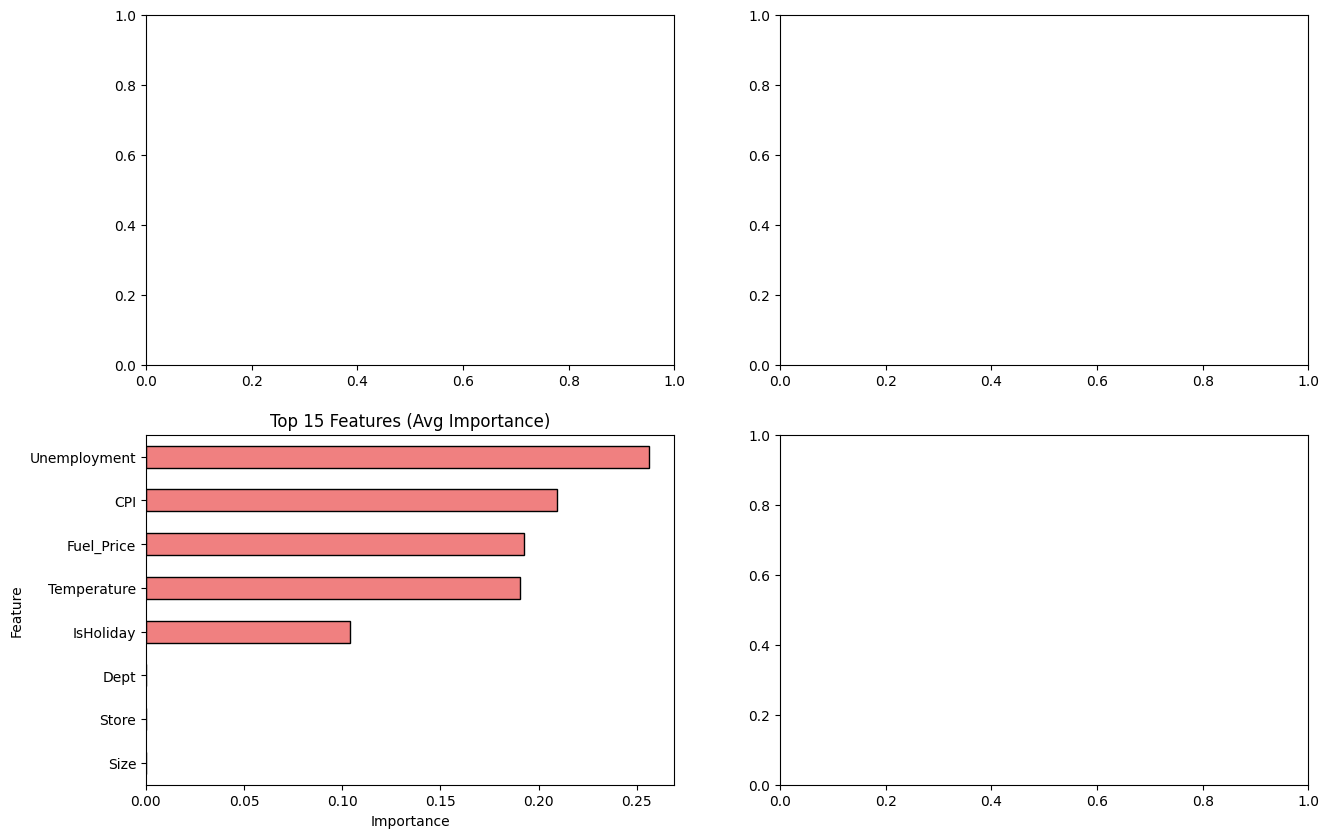

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
import time

# Load data
df = pd.read_csv('D:/St Anns/AI/Supply Chain/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Store results
all_results = []
feature_importance_summary = []

start_time = time.time()

# ============================================
# LOOP THROUGH EACH COMBINATION
# ============================================
for idx, (store, dept) in enumerate(test_cases):
    
    # Get data for this combination
    store_data = df[(df['Store'] == store) & (df['Dept'] == dept)].copy().sort_values('Date')
    
    # Split data
    train_end = '2011-06-01'
    val_end = '2012-01-01'
    
    train = store_data[store_data['Date'] < train_end]
    val = store_data[(store_data['Date'] >= train_end) & (store_data['Date'] < val_end)]
    test = store_data[store_data['Date'] >= val_end]
    
    # Prepare features
    feature_cols = ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 
                    'Unemployment', 'IsHoliday', 'Size']
    
    X_train = train[feature_cols].fillna(0)
    X_val = val[feature_cols].fillna(0)
    X_test = test[feature_cols].fillna(0)
    
    y_train = train['Weekly_Sales']
    y_val = val['Weekly_Sales']
    y_test = test['Weekly_Sales']
    
    # Combine train and val for final training
    X_train_full = pd.concat([X_train, X_val])
    y_train_full = pd.concat([y_train, y_val])
    
    xgb = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    # Store feature importance from XGBoost
    importance = pd.DataFrame({
        'Store': store,
        'Dept': dept,
        'Store_Type': store_data['Type'].iloc[0],
        'Feature': feature_cols,
        'Importance': xgb.feature_importances_
    })
    feature_importance_summary.append(importance)

# ============================================
# FEATURE IMPORTANCE SUMMARY
# ============================================
all_importance = pd.concat(feature_importance_summary, ignore_index=True)
top_features = all_importance.groupby('Feature')['Importance'].mean().sort_values(ascending=False).head(15)

print("\n🔑 Top 15 Features Across All Combinations:")
for i, (feature, imp) in enumerate(top_features.items(), 1):
    print(f"  {i}. {feature}: {imp:.4f}")

# ============================================
# VISUALIZATIONS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Feature importance
top_features.plot(kind='barh', ax=axes[1,0], color='lightcoral', edgecolor='black')
axes[1,0].set_title('Top 15 Features (Avg Importance)')
axes[1,0].set_xlabel('Importance')
axes[1,0].invert_yaxis()

plt.show()

# ============================================
# SAVE RESULTS
# ============================================
all_importance.to_csv('feature_importance_xgb.csv', index=False)